### Imports

In [79]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt


### Constants

In [80]:
MODEL_NAME = 'cnn_classifier'
MODEL_VERSION = 'v1.0'
MODEL_PATH = f'models/{MODEL_NAME}_{MODEL_VERSION}.keras'
LOAD_MODEL = True

BEST_ACC_ON_TEST = 0.80

NO_CLASSES = 10
IMG_SIZE = 32
CHANNELS = 3

hyperparameters = {
    'learning_rate': 0.001,
    'epochs': 2000,
    'batch_size': 64,
    'validation_split': 0.2,
    'early_stopping_patience': 5,

    'optimizer': 'adam',
    'loss_fn': 'categorical_crossentropy', # suitable for one-hot encoded labels
    'metrics': ['accuracy'],
}

# Loading and preprocessing data

In [81]:
# Loading the CIFAR-10 dataset
cifar10 = tf.keras.datasets.cifar10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalize the data between 0 and 1
x_train, x_test  = x_train / 255.0, x_test / 255.0

# One-hot encoding the labels
y_train = tf.keras.utils.to_categorical(y_train, NO_CLASSES)
y_test = tf.keras.utils.to_categorical(y_test, NO_CLASSES)

# Building the model

In [82]:
def build_cnn_v1(input_shape=(IMG_SIZE, IMG_SIZE, CHANNELS), num_classes=NO_CLASSES):
    # Building the Convolutional Neural Network (CNN) model
    # - Convolutional layers to extract features from images
    # - MaxPooling layers to reduce the spatial dimensions of the feature maps
    #    - Goal: separate the feature extraction from reduction of dimensions
    # - Dropout layers to prevent overfitting
    return Sequential([
        # 1. Conv-Block
        Conv2D(32, (3,3), padding='same', activation='relu', input_shape=input_shape),
        # BatchNormalization(),
        # Conv2D(32, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.25),

        # 2. Conv-Block
        Conv2D(64, (3,3), padding='same', activation='relu'),
        # BatchNormalization(),
        # Conv2D(64, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.25),

        # 3. Conv-Block
        Conv2D(128, (3,3), padding='same', activation='relu'),
        # BatchNormalization(),
        # Conv2D(128, (3,3), padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2,2)),
        Dropout(0.25),

        # Dense Layers
        Flatten(),
        Dense(512, activation='relu'),
        Dropout(0.5),
        Dense(num_classes, activation='softmax')
    ])

In [83]:
if LOAD_MODEL:
    print(f"Loading model from {MODEL_PATH}")
    model = load_model(MODEL_PATH)
else:
    print("Building a new model")
    model = build_cnn_v1()

model.compile(
    optimizer=hyperparameters['optimizer'],
    loss=hyperparameters['loss_fn'], 
    metrics=hyperparameters['metrics']
)

model.summary()

Loading model from models/cnn_classifier_v1.0.keras


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,13

 Total params: 1,343,018 (5.12 MB)

 Trainable params: 1,342,122 (5.12 MB)

 Non-trainable params: 896 (3.50 KB)

# Training & testing

In [84]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=hyperparameters['early_stopping_patience'],
    restore_best_weights=True  # save best weights during training (available in model itself after training)
)

history = model.fit(
    x_train,
    y_train,
    epochs=hyperparameters['epochs'],
    batch_size=hyperparameters['batch_size'],
    validation_split=hyperparameters['validation_split'],  # use 20% of training data for validation
    callbacks=[early_stop]
)

eval_loss, eval_accuracy = model.evaluate(x_test, y_test)
print(f"Accuracy on test set: {eval_accuracy:.2f}\nBest Accuracy yet: {BEST_ACC_ON_TEST}.")

Epoch 1/2000
625/625 ━━━━━━━━━━━━━━━━━━━━ 69s 107ms/step - accuracy: 0.8991 - loss: 0.2922 - val_accuracy: 0.9257 - val_loss: 0.2321
Epoch 2/2000
625/625 ━━━━━━━━━━━━━━━━━━━━ 73s 116ms/step - accuracy: 0.9066 - loss: 0.2673 - val_accuracy: 0.9468 - val_loss: 0.1594
Epoch 3/2000
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 118ms/step - accuracy: 0.9141 - loss: 0.2519 - val_accuracy: 0.9405 - val_loss: 0.1720
Epoch 4/2000
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 122ms/step - accuracy: 0.9163 - loss: 0.2388 - val_accuracy: 0.9256 - val_loss: 0.2123
Epoch 5/2000
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 123ms/step - accuracy: 0.9201 - loss: 0.2342 - val_accuracy: 0.9304 - val_loss: 0.2039
Epoch 6/2000
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 123ms/step - accuracy: 0.9219 - loss: 0.2235 - val_accuracy: 0.9254 - val_loss: 0.2146
Epoch 7/2000
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 123ms/step - accuracy: 0.9226 - loss: 0.2191 - val_accuracy: 0.9226 - val_loss: 0.2238
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.8474 - loss: 

In [85]:
model.save(MODEL_PATH)

# Plot results

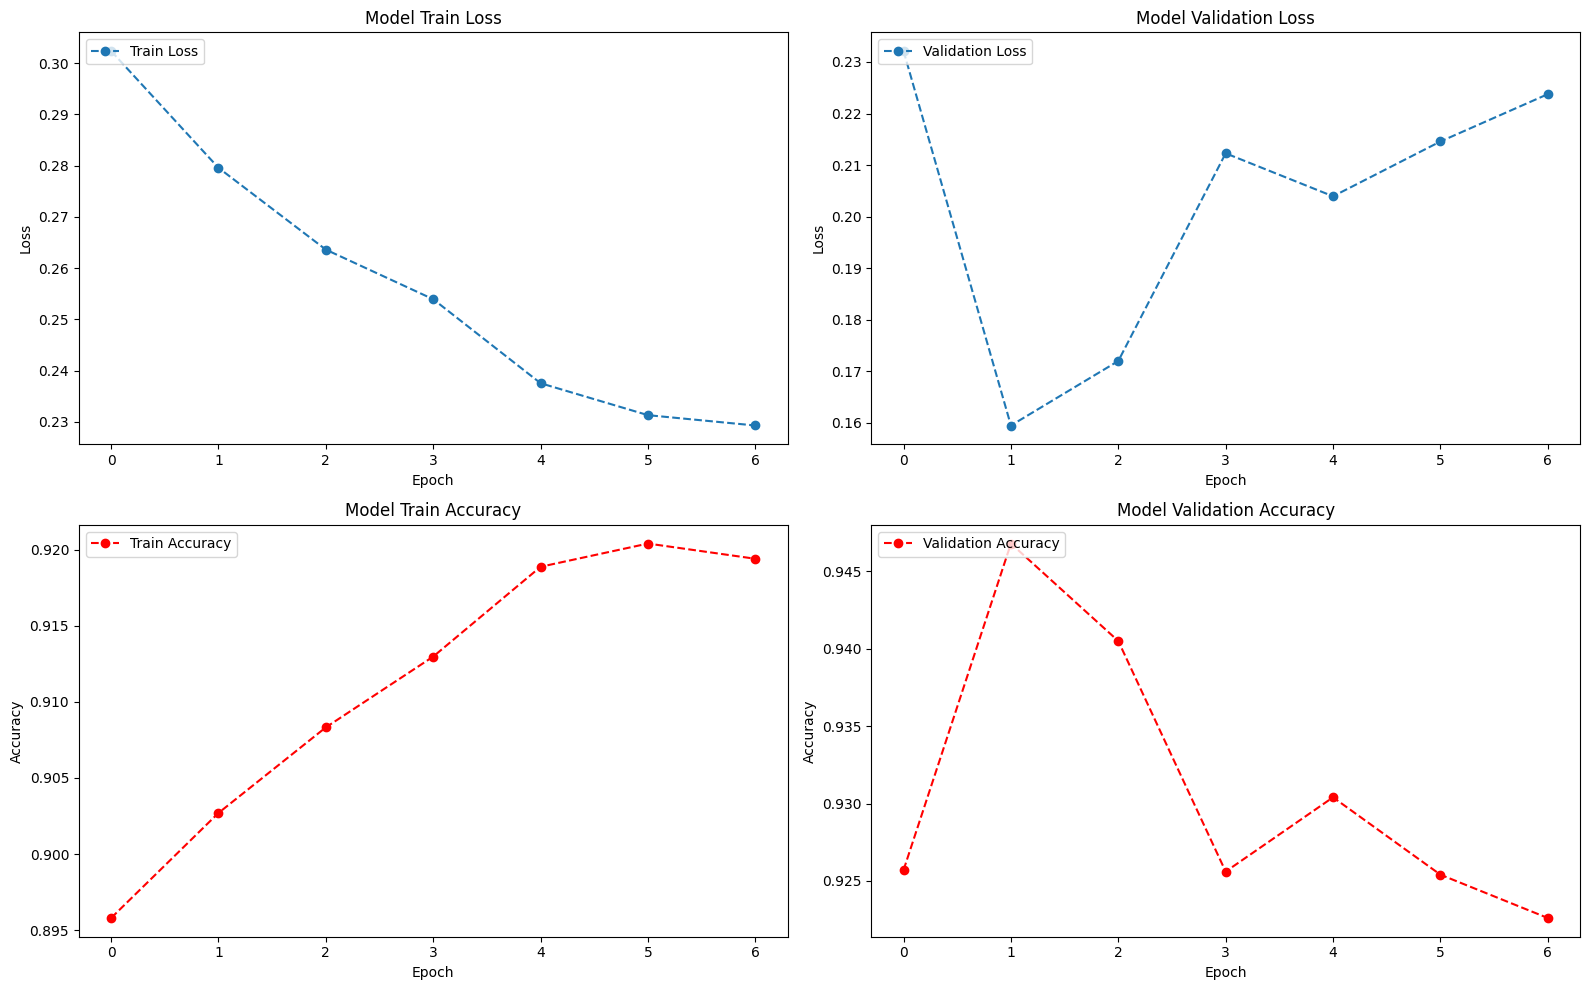

In [86]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))  # 1 Zeile, 2 Spalten

# Loss-Plot
axs[0][0].plot(history.history['loss'], 'o--')
axs[0][0].set_title('Model Train Loss')
axs[0][0].set_xlabel('Epoch')
axs[0][0].set_ylabel('Loss')
axs[0][0].legend(['Train Loss'], loc='upper left')

axs[0][1].plot(history.history['val_loss'], 'o--')
axs[0][1].set_title('Model Validation Loss')
axs[0][1].set_xlabel('Epoch')
axs[0][1].set_ylabel('Loss')
axs[0][1].legend(['Validation Loss'], loc='upper left')

# Accuracy-Plot
axs[1][0].plot(history.history['accuracy'], 'ro--')
axs[1][0].set_title('Model Train Accuracy')
axs[1][0].set_xlabel('Epoch')
axs[1][0].set_ylabel('Accuracy')
axs[1][0].legend(['Train Accuracy'], loc='upper left')

axs[1][1].plot(history.history['val_accuracy'], 'ro--')
axs[1][1].set_title('Model Validation Accuracy')
axs[1][1].set_xlabel('Epoch')
axs[1][1].set_ylabel('Accuracy')
axs[1][1].legend(['Validation Accuracy'], loc='upper left')

plt.tight_layout()
plt.show()
